In [1]:
# --- FASE 1: PREPARACIÓN DEL ENTORNO ---
# Importamos las librerías necesarias para análisis y Machine Learning
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Librerías específicas para el Modelo Random Forest
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Configuración de estilo para los gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga del Dataset (Atención: el separador es punto y coma)
df = pd.read_csv('zara.csv', sep=';')

print("✅ Entorno listo y datos cargados.")
print(f"Tenemos {df.shape[0]} productos y {df.shape[1]} columnas.")
df.head(3) # Vista previa de las primeras filas

✅ Entorno listo y datos cargados.
Tenemos 252 productos y 16 columnas.


,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN


--- ¿Faltan datos? (Nulos) ---
Product ID          0
Product Position    0
Promotion           0
Product Category    0
Seasonal            0
Sales Volume        0
brand               0
url                 0
sku                 0
name                1
description         2
price               0
currency            0
scraped_at          0
terms               0
section             0
dtype: int64


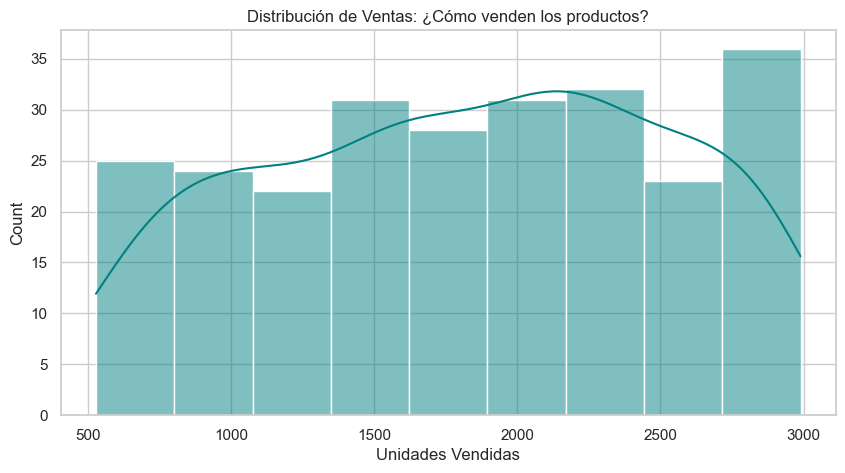

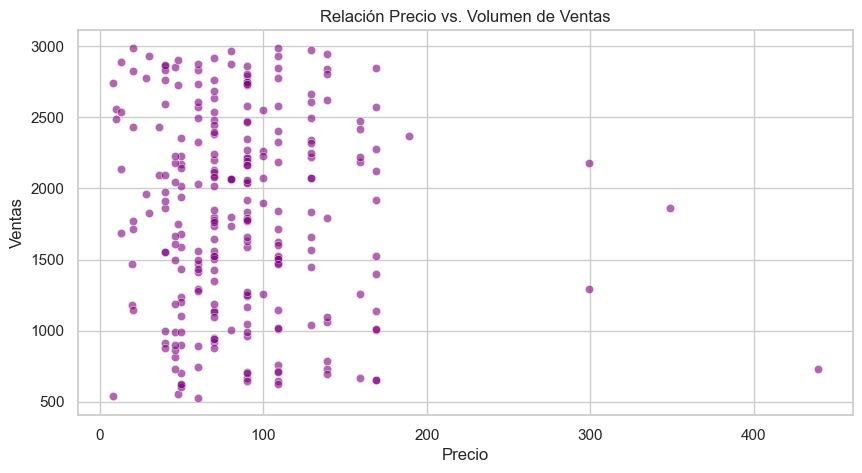

In [2]:
# --- FASE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA) ---

# 1. Revisión de Nulos (Limpieza)
print("--- ¿Faltan datos? (Nulos) ---")
print(df.isnull().sum())

# 2. Análisis del Objetivo: Ventas (Sales Volume)
plt.figure(figsize=(10, 5))
sns.histplot(df['Sales Volume'], kde=True, color='teal')
plt.title('Distribución de Ventas: ¿Cómo venden los productos?')
plt.xlabel('Unidades Vendidas')
plt.show()

# 3. Relación Clave: Precio vs Ventas
# ¿Los productos más caros se venden menos?
plt.figure(figsize=(10, 5))
sns.scatterplot(x='price', y='Sales Volume', data=df, alpha=0.6, color='purple')
plt.title('Relación Precio vs. Volumen de Ventas')
plt.xlabel('Precio')
plt.ylabel('Ventas')
plt.show()

In [3]:
# --- FASE 3: DEFINICIÓN DEL TARGET Y VARIABLES ---

# 1. DEFINIR EL TARGET (LA META)
# Usaremos la MEDIANA para dividir las clases equilibradamente (50% éxito / 50% normal).
# Esto soluciona el problema de "malos resultados" por datos desbalanceados.
mediana_ventas = df['Sales Volume'].median()

# Creamos la columna objetivo: 1 = Éxito, 0 = Normal
df['Exito_Ventas'] = df['Sales Volume'].apply(lambda x: 1 if x > mediana_ventas else 0)

print(f"Definición de Éxito: Vender más de {mediana_ventas:.0f} unidades.")
print("Distribución del Target:", df['Exito_Ventas'].value_counts().to_dict())

# 2. SELECCIONAR FEATURES (VARIABLES PREDICTORAS)
# Elegimos las columnas que tienen sentido para el negocio
features = ['Product Position', 'Promotion', 'Seasonal', 'price', 'section']
data_model = df[features].copy()

# 3. CODIFICACIÓN (Encoding)
# Random Forest necesita números, así que convertimos el texto.
le = LabelEncoder()
cols_texto = ['Product Position', 'Promotion', 'Seasonal', 'section']

for col in cols_texto:
    data_model[col] = le.fit_transform(data_model[col])

print("✅ Datos convertidos a numéricos para el modelo.")

Definición de Éxito: Vender más de 1840 unidades.
Distribución del Target: {1: 126, 0: 126}
✅ Datos convertidos a numéricos para el modelo.


In [4]:
# --- FASE 4: MODELADO (RANDOM FOREST) ---

# 1. Definir X (Variables) e y (Objetivo)
X = data_model
y = df['Exito_Ventas']

# 2. División Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Crear y Entrenar el Modelo
# n_estimators=100 -> Usa 100 árboles de decisión para votar
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("🌲 Modelo Random Forest entrenado exitosamente.")

🌲 Modelo Random Forest entrenado exitosamente.


🎯 PRECISIÓN FINAL: 60.78%


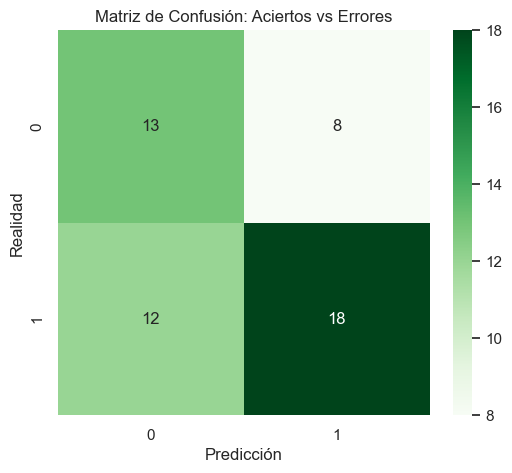

C:\Users\danie\AppData\Local\Temp\ipykernel_25156\3009999134.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Peso', y='Variable', data=importancia, palette='viridis')


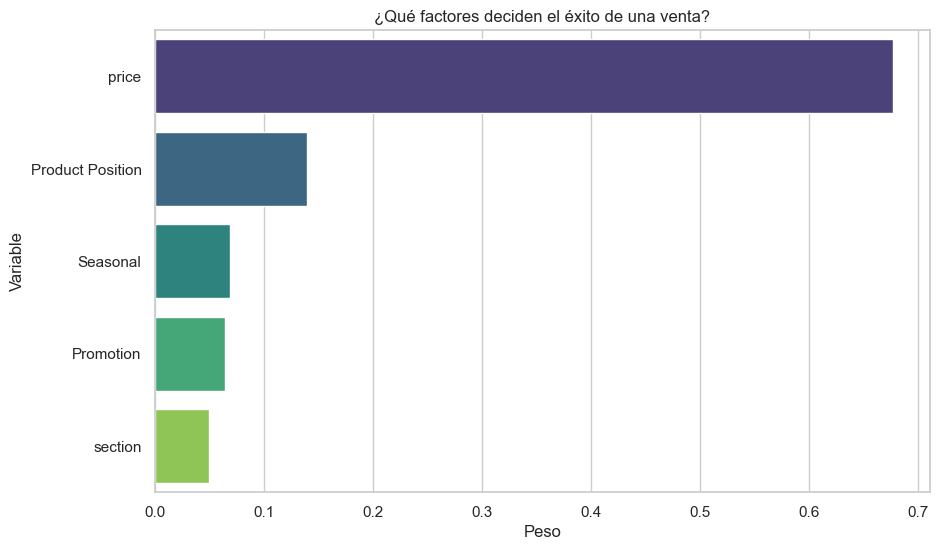


💡 CONCLUSIÓN DEL ANÁLISIS:
El modelo ha detectado que 'price' es el factor más determinante.
Para maximizar ventas, Zara debe optimizar sus estrategias de 'price'.


In [5]:
# --- FASE 5: EVALUACIÓN Y COMUNICACIÓN ---

# 1. Predicciones
y_pred = rf_model.predict(X_test)

# 2. Precisión (Accuracy)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 PRECISIÓN FINAL: {acc*100:.2f}%")

# 3. Matriz de Confusión (Gráfico de Aciertos)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión: Aciertos vs Errores')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

# 4. GRÁFICO DE IMPORTANCIA (¡Lo más valioso para el negocio!)
# Nos dice qué variable afecta más a las ventas
importancia = pd.DataFrame({
    'Variable': features,
    'Peso': rf_model.feature_importances_
}).sort_values(by='Peso', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Peso', y='Variable', data=importancia, palette='viridis')
plt.title('¿Qué factores deciden el éxito de una venta?')
plt.show()

# 5. CONCLUSIÓN AUTOMÁTICA
top_feature = importancia.iloc[0]['Variable']
print(f"\n💡 CONCLUSIÓN DEL ANÁLISIS:")
print(f"El modelo ha detectado que '{top_feature}' es el factor más determinante.")
print(f"Para maximizar ventas, Zara debe optimizar sus estrategias de '{top_feature}'.")